In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))

from core.llm_good_enough import LLMGoodEnough


# PolitiFact S6 — Analysis

6-point scale dataset.

Data preprocessing is done in `preprocessing.ipynb`.


In [3]:
# Load cleaned S6 data
df = pd.read_csv("../data/merged_s6_cleaned.csv")
print(f"Loaded S6 data: {df.shape}")

# Identify human columns
HUMAN_COLS = [c for c in df.columns if c.startswith("human_#")]
LLM_COLS = ["GPT-4o mini"]

# Determine score boundaries from human ratings
unique_human_ratings = np.unique(df[HUMAN_COLS].values[~pd.isna(df[HUMAN_COLS].values)])
MIN_SCORE, MAX_SCORE = int(np.min(unique_human_ratings)), int(np.max(unique_human_ratings))
print(f"Human rating scale: {unique_human_ratings}")

df.head()

Loaded S6 data: (120, 32)
Human rating scale: [0. 1. 2. 3. 4. 5.]


,statement,GPT-4o mini,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,human_#9,human_#10,human_#11,human_#12,human_#13,human_#14,human_#15,human_#16,human_#17,human_#18,human_#19,human_#20,human_#21,human_#22,human_#23,human_#24,human_#25,human_#26,human_#27,human_#28,human_#29,human_#30
0,22 times Barack Obama said he did not have the...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
SEED = 42

good_enough = LLMGoodEnough(
    df=df,
    human_cols=HUMAN_COLS,
    llm_cols=LLM_COLS,
    min_score=MIN_SCORE,
    max_score=MAX_SCORE,
    seed=SEED,
    verbosity=1
)


🎲 Random seed: 42
✅ Found 30 valid human annotator columns.
✅ Keeping 36/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


## LLM vs Human disagreement


✅ Computed LLM-human disagreements for 1 LLM columns.
✅ Figure saved as PDF → ../figures/pdf/politifact_s6_barplot.pdf


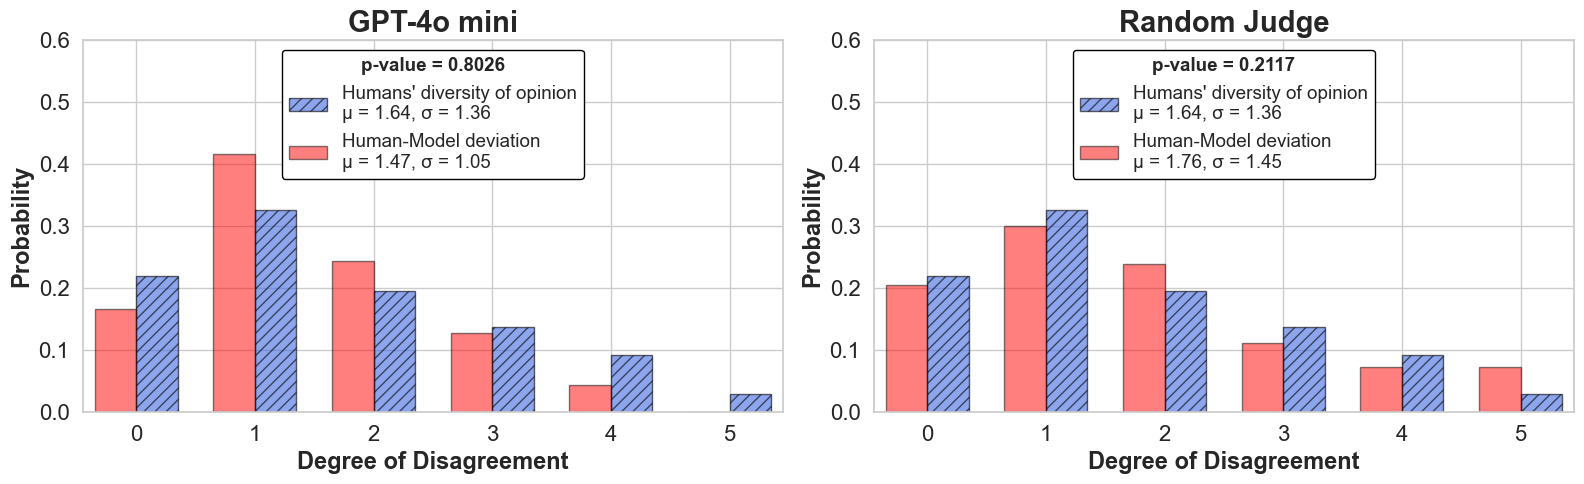

In [5]:
good_enough.plot_judges_grid(
    save_path="../figures/pdf/politifact_s6_barplot.pdf"
)

## Robustness (Monte Carlo)


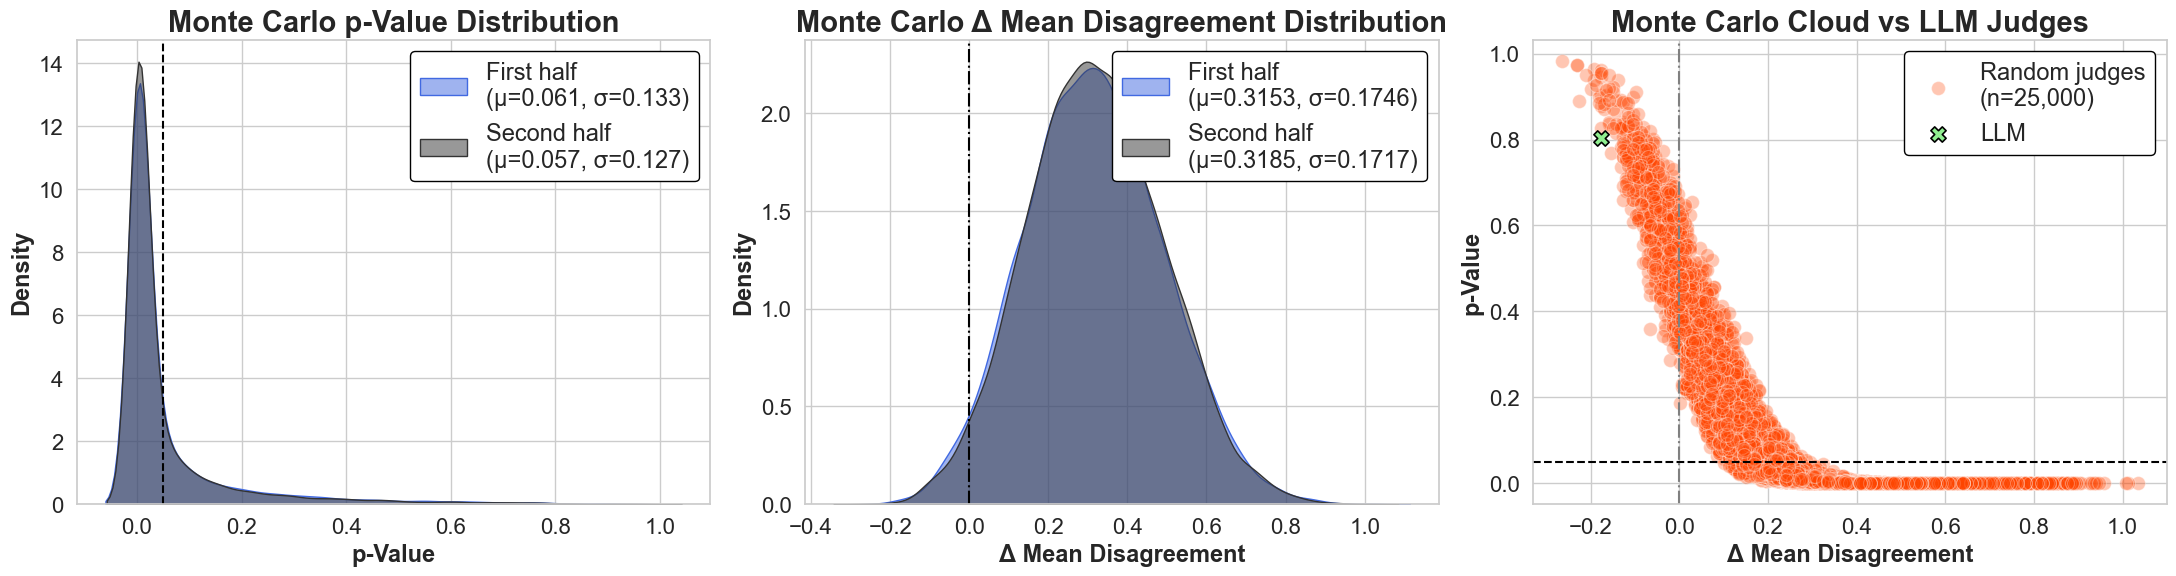

In [6]:
good_enough.plot_monte_carlo_robustness(
    llm_col="GPT-4o mini",
    save_path="../figures/pdf/politifact_s6_monte_carlo_robustness.pdf"
)

In [7]:
# P-value distribution analysis
counts = good_enough.count_pvalue_samples(iterations=25_000, threshold=0.05)

print("=" * 60)
print("P-value Distribution Analysis (S6)")
print("=" * 60)
print(f"Total Monte Carlo samples: {counts['total']:,}")
print(f"\nSamples with p-value > 0.05:  {counts['above']:,} ({counts['above_pct']:.2f}%)")
print(f"Samples with p-value ≤ 0.05:  {counts['below']:,} ({counts['below_pct']:.2f}%)")
print("=" * 60)

TypeError: LLMGoodEnough._monte_carlo_random_judges() got an unexpected keyword argument 'human_dis'

In [ ]:
xxx

## Human stability analysis


In [ ]:
good_enough.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../figures/pdf/politifact_s6_human_stability.pdf",
    parallel=True,
)

In [ ]:
good_enough.plot_human_stability_analysis(
    percentages=[50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../figures/pdf/politifact_s6_human_stability_100plus.pdf",
    parallel=True,
)

## LLM stability analysis

✅ Figure saved → ../figures/svg/politifact_s3_llm_stability.svg


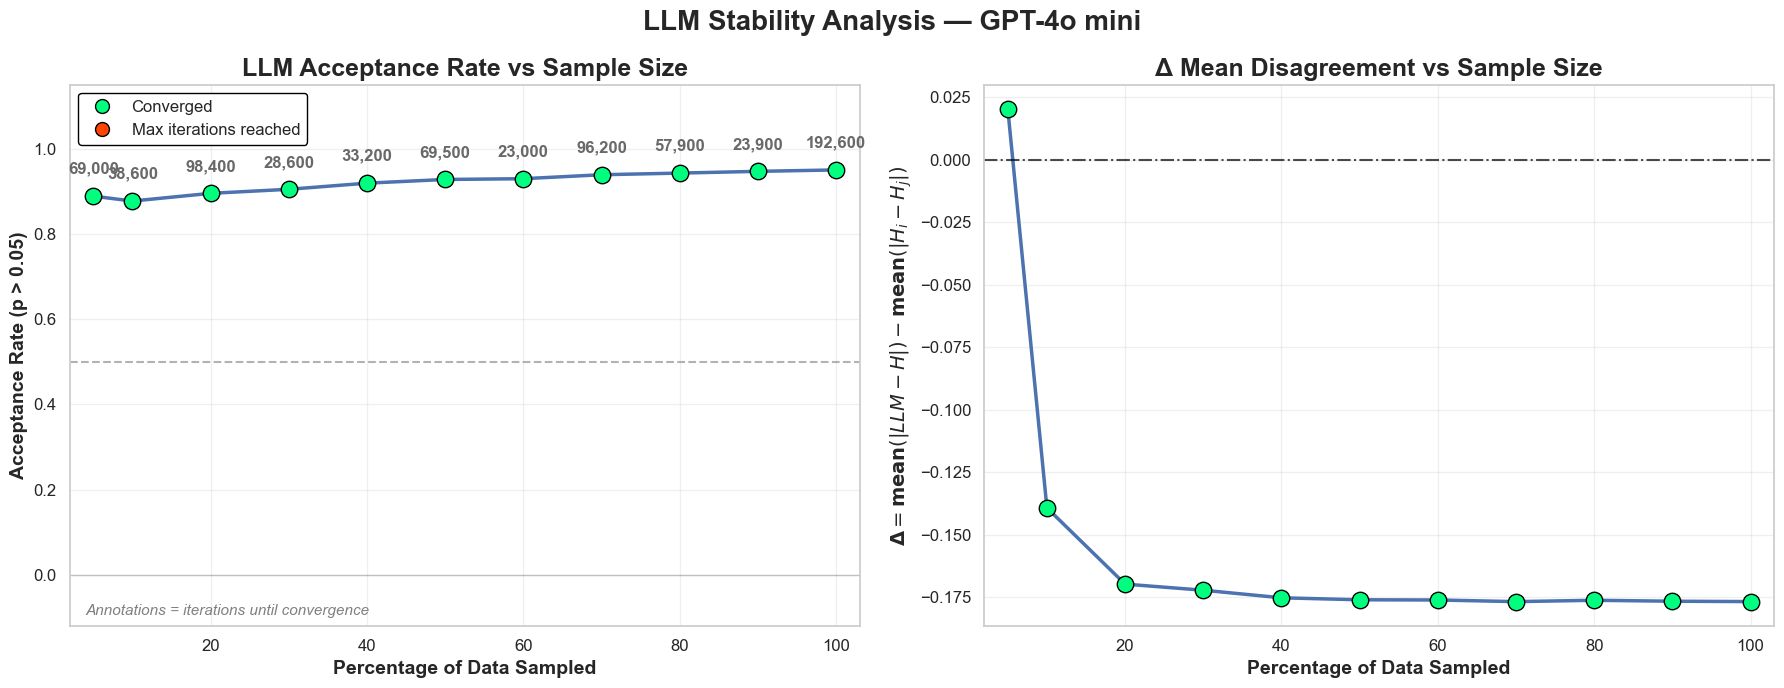

In [ ]:
good_enough.plot_llm_stability_analysis(
    llm_col="GPT-4o mini",
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../figures/pdf/politifact_s6_llm_stability.pdf",
    parallel=True,
)